<a href="https://colab.research.google.com/github/Azi-Lizzy/ii-dlsca/blob/main/01_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Ensemble Learning

This exercise demonstrates how combining several sub-optimal neural networks into an ensemble can improve the performance of a deep learning-based side-channel attack (DL-SCA). You will work with traces collected from a masked software implementation of Ascon and compare the attack performance of a single model with that of an ensemble of five models.

Finding suitable neural networks through random architecture search and training requires substantial time and computational resources. We have therefore completed these steps in advance: we generated and trained 60 MLPs with different architectures, then selected the five best-performing models based on their guessing entropy (GE). These five pretrained models are available through the Zenodo link below. No model training is required for this exercise.

Your objective in of this exercise is to investigate whether combining the predictions of these five models achieves a lower GE than using the best model among the 6 random generated models. GE measures the average rank of the correct key hypothesis; lower values indicate a more effective attack. In this notebook, ranks start at 1, so GE = 1 is the best possible result.


The exercise consists of two steps:

- Evaluate the best individual model: Load the best pretrained model and use it to predict class probabilities for the attack traces. Convert these predictions into scores for the key hypotheses, then calculate GE as a function of the number of attack traces.

- Evaluate the ensemble of five models: Load the five pretrained models one at a time and obtain their predictions for the same attack traces. Combine their contributions by summing the log probabilities assigned to each key hypothesis, then calculate the ensemble’s GE.

Finally, plot both GE curves together. Compare the final GE and the number of traces required to reach GE = 1, if achieved. What does this comparison reveal about the benefit of combining models that are individually insufficient for reliable key recovery?


## Preparations

Let’s start by setting up your Google Colab environment.

Run the cell below by clicking the ▶ button or pressing Shift + Enter. It installs the libraries needed for this exercise. Wait until the installation finishes before moving to the next cell.

You only need to run this installation once per Colab runtime session.

In [3]:
!pip install numpy
!pip install h5py
!pip install trsfile
!pip install tensorflow==2.22.0rc0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.3/638.3 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 26.4 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires

## Download the dataset and the models

Next, download the Ascon dataset and pretrained models used in this exercise.

Run the cell below to download the files from Zenodo into your Colab environment. Wait until the download finishes before continuing.

You only need to run this cell once per Colab runtime session. The downloaded files and folders will be stored in /content/. You can find them by clicking the folder icon in Colab’s left sidebar.

In [4]:
# Run this for the zip file of the models:

!wget https://zenodo.org/records/23102432/files/Ensemble-Trained-Models.zip?download=1 -O Ensemble-Trained-Models.zip
!unzip Ensemble-Trained-Models.zip
!rm Ensemble-Trained-Models.zip

# Run this for the dataset that is already in the original format:
!wget 'https://zenodo.org/records/23083982/files/Ascon-Protected.trs?download=1' -O Ascon-Protected.trs


--2026-10-03 17:38:55--  https://zenodo.org/records/23102432/files/Ensemble-Trained-Models.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.184.98.114, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8633270 (8.2M) [application/octet-stream]
Saving to: ‘Ensemble-Trained-Models.zip’

Ensemble-Trained-Mo 100%[===================>]   8.23M   804KB/s    in 11s     

2026-10-03 17:39:07 (750 KB/s) - ‘Ensemble-Trained-Models.zip’ saved [8633270/8633270]

Archive:  Ensemble-Trained-Models.zip
   creating: Ensemble-Trained-Models/
  inflating: Ensemble-Trained-Models/sub-optimal-model-0.keras  
  inflating: Ensemble-Trained-Models/sub-optimal-model-1.keras  
  inflating: Ensemble-Trained-Models/sub-optimal-model-2.keras  
  inflating: Ensemble-Trained-Models/sub-optimal-model-3.keras  
  inflating: Ensemble-Trained-Models/sub-optimal-model-4.keras  
--2026-10-03 17:39:07-


## Load the Dataset
Let’s start by loading the dataset. It contains power traces from a **32-bit optimized implementation of Ascon-128 v1.2 protected with first-order domain-oriented masking (DoM)**. The Ascon team’s C implementations are available in their [GitHub repository](https://github.com/ascon/ascon-c).

The traces were collected using a ChipWhisperer-Lite board and an oscilloscope with 8-bit resolution. They capture the **first permutation round during Ascon’s initialization phase**, with **1,408 power samples per trace**.

Each trace also includes the **16-byte key** used for that encryption and the **16-byte public nonce**, which changes with each new encryption. The nonce is stored as two 8-byte parts: `nonce0` and `nonce1`.

**Run the cell below** to load the dataset. For more information about its structure, see the [dataset descrip
tion on Zenodo](https://zenodo.org/records/10229484).

In [5]:
import numpy as np
import trsfile

# Dataset settings: edit the path for your computer.
dataset_file = '/content/Ascon-Protected.trs'
n_profiling = 50000
n_attack = 5000
number_of_samples = 1408
target_byte = 4                 # 0..7, in the first key word
leakage_model = 'SB-8'          # 'SB-8' (256 classes). For Ascon SB-8 is equivalent to ID

assert 0 <= target_byte < 8
assert leakage_model in ('SB-8', 'HW')

# Read the profiling and attack blocks.
n_total = n_profiling + n_attack
samples = np.zeros((n_total, number_of_samples), dtype=np.float64)
nonces = np.zeros((n_total, 16), dtype=np.uint8)
keys = np.zeros((n_total, 16), dtype=np.uint8)

with trsfile.open(dataset_file, 'r') as traces:
    for i in range(n_total):
        trace = traces[i]
        samples[i] = trace.samples
        keys[i] = np.frombuffer(bytes(trace.parameters['key'].value), dtype=np.uint8)
        nonces[i, :8] = np.frombuffer(bytes(trace.parameters['nonce0'].value), dtype=np.uint8)
        nonces[i, 8:] = np.frombuffer(bytes(trace.parameters['nonce1'].value), dtype=np.uint8)

# We break the keys and nonces into two 8-byte halves, to match state of the Ascon and its implementation.
key0 = keys[:, 0:8]
key1 = keys[:, 8:16]
nonces0 = nonces[:, 0:8]
nonces1 = nonces[:, 8:16]

X_profiling = samples[:n_profiling]
X_attack = samples[n_profiling:]

# Profiling data is needed anymore as we already have the trained models.
attack_data = np.zeros((n_attack, 4), dtype=np.uint8)
attack_data[:, 0] = key0[n_profiling:, target_byte]
attack_data[:, 1] = key1[n_profiling:, target_byte]
attack_data[:, 2] = nonces0[n_profiling:, target_byte]
attack_data[:, 3] = nonces1[n_profiling:, target_byte]

good_key = int(attack_data[0, 0])
assert np.all(attack_data[:, 0] == good_key), 'The attacked key byte must be fixed.'

# Apply the original z-score normalization, using profiling statistics only.
# The profiling data is just used to reproduce the z-score normalization parameters.
z_score_mean = np.mean(X_profiling, axis=0)
z_score_std = np.std(X_profiling, axis=0)
z_score_std[z_score_std == 0] = 1  # Avoid division by zero for constant samples.
X_attack = ((X_attack - z_score_mean) / z_score_std).astype('float32')

# Profiling samples are no longer needed: there is no training.
del samples, X_profiling, nonces, keys, key0, key1, nonces0, nonces1
print('Attack traces:', X_attack.shape)
print('Correct key byte:', good_key)

Attack traces: (5000, 1408)
Correct key byte: 45


## Load the Best Model and Calculate Its Guessing Entropy

With the time and computational resources available, we generated and trained **60 neural networks using random search**. Some models failed to achieve a low guessing entropy (GE), while others performed better. We selected the model with the **lowest GE** as our best individual model.

In this step, you will **load this pretrained model**, use it to predict class probabilities for the attack traces, and calculate its GE using the formula introduced during the presentation.
### Attack Point and the SB-8 Leakage Model

At initialization, Ascon’s state consists of five 64-bit words:

$$
(x_0, x_1, x_2, x_3, x_4)
=
(\mathrm{IV}, \mathrm{key0}, \mathrm{key1},
\mathrm{nonces0}, \mathrm{nonces1})
$$

Here, `IV` is a public constant, `key0` and `key1` are the two halves of the secret key, and `nonces0` and `nonces1` are the two halves of the public nonce.

Our **attack point** is $y_4$, the fifth state word immediately after the S-box layer in the first permutation round. Its only secret input is `key0`; the other inputs are public.

We use a **divide-and-conquer strategy** to recover `key0` one byte at a time. For a chosen byte position $i \in \{0,\ldots,7\}$, the targeted intermediate value is:

$$
Y_{4,i} =
\left[
\mathrm{key0}_i \mathbin{\&}
\left(255 \oplus \mathrm{IV}_i \oplus \mathrm{nonces1}_i\right)
\right]
\oplus \mathrm{nonces0}_i
\oplus \mathrm{nonces1}_i
$$

Here, $\oplus$ denotes bitwise XOR, $\&$ denotes bitwise AND, and each subscripted input represents the byte at position $b$.

This is the **SB-8 leakage model**. The label during the trainig of neural networks and the prediction target during the attack are the actual value of one byte of $y_4$ (here byte 4). It therefore has **256 possible classes**, from 0 to 255.

If you want to know more about the SB-8 leakage model please look at this paper **One for All, All for Ascon: Ensemble-based Deep Learning Side-channel Analysis**.

### Calculating Guessing Entropy (GE)

For each key-byte hypothesis $k$, accumulate its log-probability score over $n$ attack traces:

$$
S_k(n) = \sum_{i=1}^{n}
\log\left(p_i\left[f(k,\mathrm{nonce}_i)\right] + \varepsilon\right)
$$

Sort the 256 key hypotheses by their scores, from highest to lowest, and record the rank of the correct key byte $k^\star$.

Repeat the attack with different trace orders and average these ranks:

$$
{
\mathrm{GE}(n) = \frac{1}{R}
\sum_{r=1}^{R} \operatorname{rank}_{r,n}(k^\star)
}
$$

Here:

- $p_i[c]$ is the model's predicted probability of class $c$ for trace $i$.
- $f(k,\mathrm{nonce}_i)$ is the intermediate-value class calculated using key hypothesis $k$, the known nonce, and the fixed IV.
- $\varepsilon$ is a small constant, such as $10^{-40}$, to avoid $\log(0)$.
- $R$ is the number of attack repetitions.
- $\operatorname{rank}_{r,n}(k^\star)$ is the correct key's rank after $n$ traces in repetition $r$.

**Lower GE is better.** This notebook uses one-based ranks, so **GE = 1** means the correct key hypothesis ranks first in every repetition.


### Fill in the Gaps

Complete the missing code in the cell below to practice **loading a pretrained model** and **using its predicted class probabilities to calculate GE for a single model**.

A comment above each gap explains what you need to do and where to find a hint. Once you have filled in all the gaps, run the cell to evaluate the model and plot its GE.



In [12]:
# Loading the models and getting the probabilities
path_models = "/content/Ensemble-Trained-Models/"

from pathlib import Path
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
import gc

batch_size = 128

# assert model_files and len(set(model_files)) == len(model_files), 'Use unique model filenames.'
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # The GPU may already be initialized if this cell is rerun.

best_model_probabilities = []

# TODO:
# Check how to use tensorflow.keras.models.load_model().
# Set the path to best-found-model.keras in /content/Ensemble-Trained-Models/,
# then load the pretrained model with compile=False.

model_file = Path(...)
model = load_model(...)

# TODO:
# Check how to use model.predict().
# Use the loaded model to predict class probabilities for the attack traces (X_attack).
best_model_probabilities = ...

expected_classes = 256
assert best_model_probabilities.shape == (n_attack, expected_classes), 'Unexpected model output shape.'

del model
K.clear_session()
gc.collect()

print('Predictions available for', len(best_model_probabilities), 'model(s).')

Loading best-found-model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Predictions available for 5000 model(s).


In [14]:
# Calculating GE

from sklearn.utils import shuffle
import matplotlib.pyplot as plt

runs = 50
num_attack_traces = 3000
assert runs > 0 and 0 < num_attack_traces <= n_attack


def calculate_ge(log_probabilities):
    iv = [128, 64, 12, 6, 0, 0, 0, 0]
    nonce0 = attack_data[:, 2]
    nonce1 = attack_data[:, 3]

    hypothesis_probabilities = np.zeros((n_attack, 256))

    for index in range(n_attack):
        for hypothesis in range(256):
            key0 = hypothesis
            #TODO
            # Use the SB-8 (y4) relation to calculate the hypothetical value of y4 if the key0 is equal to the hypotetical key, hypothesis.
            hypothetical_value = ...
            # Then we use the prediction probability for this hypothetical_value as the probability of key0 = hypothesis
            hypothesis_probabilities[index, hypothesis] = log_probabilities[index, hypothetical_value]

    # Accumulate scores and average the correct-key rank over repeated attacks.
    key_ranking_sum = np.zeros(num_attack_traces)
    for run in range(runs):
        shuffled_probabilities = shuffle(hypothesis_probabilities, random_state=0)
        key_probabilities = np.zeros(256)

        for index in range(num_attack_traces):
          # TODO:
            # 1. Add trace's log-probability scores from shuffled_probabilities
            #    according to Sk(n) in the above formula.
            ...
            # 2. Use np.argsort() to sort the key hypotheses by their accumulated
            #    scores, from highest to lowest.
            ...
            # 3. Find the position of good_key in the sorted hypotheses.
            ...
            # 4. Add the correct key's rank to key_ranking_sum[index].
            #    These ranks will later be averaged across attack repetitions.
            ...

    return key_ranking_sum / runs


log_probabilities = np.log(best_model_probabilities.astype(np.float64) + 1e-40)
ge_single = calculate_ge(log_probabilities)
print(f'Final GE for the best found model: {ge_single[-1]:.2f}')

trace_axis = np.arange(1, num_attack_traces + 1)
plt.figure(figsize=(8, 4))
plt.plot(trace_axis, ge_single, label=f'best found model')
plt.xlabel('Number of attack traces')
plt.ylabel('Guessing entropy (1-based)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


ValueError: setting an array element with a sequence.

## Load the Suboptimal Models and Calculate the Ensemble’s GE

An ensemble can improve attack performance by combining the predictions of several models, without requiring another search for a better individual model.

In this part, you will use the **five best models found during our random search**, including the best individual model evaluated in the previous section. You will compare their combined performance with that of the best model alone.

Because these models are already trained, **no additional training is needed**. Running five models requires more prediction time than running one, but combining their predictions may achieve a **lower GE with fewer attack traces**.

Your task is to **calculate the ensemble’s GE** using the method introduced during the presentation. A reminder is provided below.

Read the reminder, then **fill in the gaps in the following code cell**. Finally, compare the GE curves for the ensemble and the best individual model.

### Calculating Guessing Entropy for the Ensemble

For an ensemble of $M$ models, first combine their predictions for each trace by **summing the log probabilities** assigned to each class:

$$
s_i[c] = \sum_{m=1}^{M}
\log\left(p_i^{(m)}[c] + \varepsilon\right)
$$

The rest is the same as single mode GE calculation. For each key-byte hypothesis $k$, select the class given by the SB-8 intermediate value and accumulate its combined score over $n$ attack traces:

$$
S_k^{\mathrm{ensemble}}(n)
=
\sum_{i=1}^{n} s_i\left[f(k,\mathrm{nonce}_i)\right]
$$

Sort the 256 key hypotheses by their scores, from highest to lowest, and record the rank of the correct key byte $k^\star$.

Repeat the attack with different trace orders and average these ranks:

$$
{
\mathrm{GE}_{\mathrm{ensemble}}(n)
=
\frac{1}{R}
\sum_{r=1}^{R}
\operatorname{rank}^{\mathrm{ensemble}}_{r,n}(k^\star)
}
$$

Here:

- $M$ is the number of models; in this exercise, $M=5$.
- $p_i^{(m)}[c]$ is model $m$'s predicted probability of class $c$ for trace $i$.
- $s_i[c]$ is the combined log-probability score for class $c$ and trace $i$.
- $f(k,\mathrm{nonce}_i)$ is the SB-8 intermediate-value class calculated using key hypothesis $k$, the known nonce, and the fixed IV.
- $\varepsilon$ is a small constant, such as $10^{-40}$, to avoid $\log(0)$.
- $R$ is the number of attack repetitions.
- $\operatorname{rank}^{\mathrm{ensemble}}_{r,n}(k^\star)$ is the correct key's rank after $n$ traces in repetition $r$.


Loading sub-opt-model-0.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Loading sub-opt-model-1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Loading sub-opt-model-2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Loading sub-opt-model-3.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Loading sub-opt-model-4.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Predictions available for 5 model(s).
Final GE for the single model: 5.00
Final GE for the ensemble of 5 model(s): 1.00


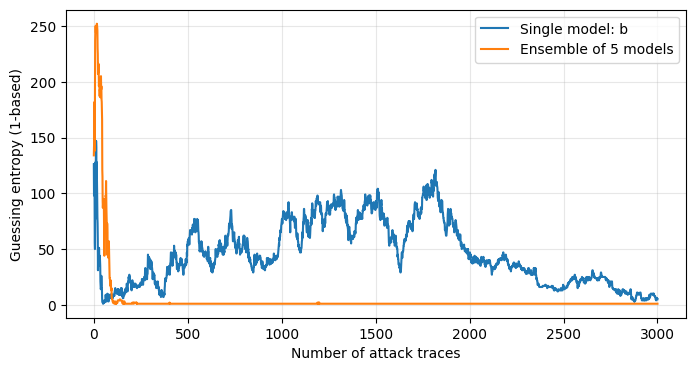

In [11]:
model_folder = Path('/content/Ensemble-Trained-Models/')
model_files = ['sub-opt-model-0.keras', 'sub-opt-model-1.keras', 'sub-opt-model-2.keras', 'sub-opt-model-3.keras', 'sub-opt-model-4.keras']
batch_size = 128

assert model_files and len(set(model_files)) == len(model_files), 'Use unique model filenames.'
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # The GPU may already be initialized if this cell is rerun.

probabilities_all = {}
for filename in model_files:
    print('Loading', filename)
    model = load_model(model_folder/filename, compile=False)

    # MLPs use (traces, samples); the original CNNs also need a channel dimension.
    probabilities = model.predict(X_attack, batch_size=batch_size, verbose=1)
    expected_classes = 256
    assert probabilities.shape == (n_attack, expected_classes), 'Unexpected model output shape.'
    probabilities_all[filename] = probabilities

    del model
    K.clear_session()
    gc.collect()

print('Predictions available for', len(probabilities_all), 'model(s).')

ensemble_log_probabilities = np.zeros_like(probabilities_all[model_files[0]], dtype=np.float64)
for filename in model_files:
    #TODO
    # Use the hint above to calculate the ensebmle GE. Note that you can call calculate_ge after ensembeling the pobabilities.
    # Call your variable ensemble_log_probabilities
    ...

ge_ensemble = calculate_ge(ensemble_log_probabilities)
print(f'Final GE for the single model: {ge_single[-1]:.2f}')
print(f'Final GE for the ensemble of {len(model_files)} model(s): {ge_ensemble[-1]:.2f}')

plt.figure(figsize=(8, 4))
plt.plot(trace_axis, ge_single, label=f'Single model: {single_model}')
plt.plot(trace_axis, ge_ensemble, label=f'Ensemble of {len(model_files)} models')
plt.xlabel('Number of attack traces')
plt.ylabel('Guessing entropy (1-based)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()